In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import export_text
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


In [36]:
df= pd.read_csv("C:\\Users\\janew\\Downloads\\Maternal Health Risk Data Set.csv")

In [37]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [38]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [40]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [41]:
df.shape

(1014, 7)

In [42]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [43]:
#getting proportions of risk level
df['RiskLevel'].value_counts(normalize=True) 
#The dataset is not perfectly balanced, but the distribution is fairly even.
#Low risk is the majority class, while High risk is the minority.

low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: RiskLevel, dtype: float64

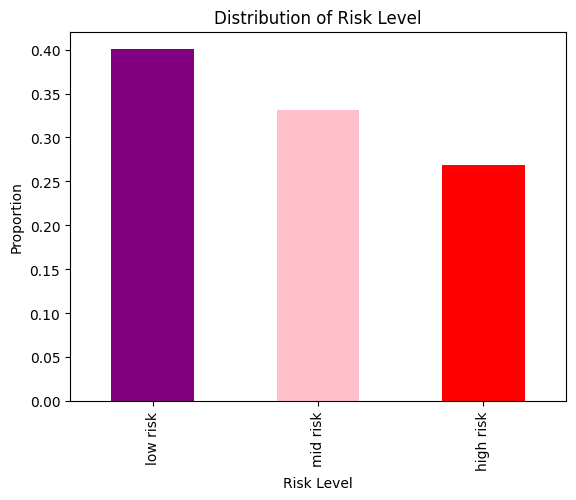

In [44]:
#Visualizing proportions
df['RiskLevel'].value_counts(normalize=True).plot(
    kind='bar',
    color=['purple','pink','red']
)
plt.title("Distribution of Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Proportion")
plt.show()


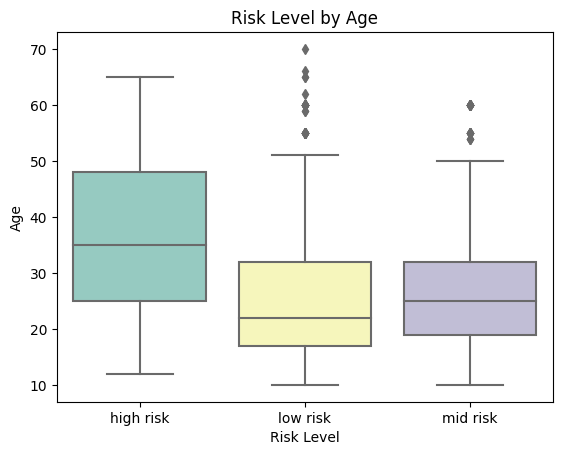

In [45]:
# Risk Level by Age
sns.boxplot(x='RiskLevel', y='Age', data=df, palette='Set3')
plt.title("Risk Level by Age")
plt.xlabel("Risk Level")
plt.ylabel("Age")
plt.show()
#Older mothers are at higher risk
#The younger ages are concentrated at low risk with few outliers at 50
#For mid- risk the median age is between low risk and high risk

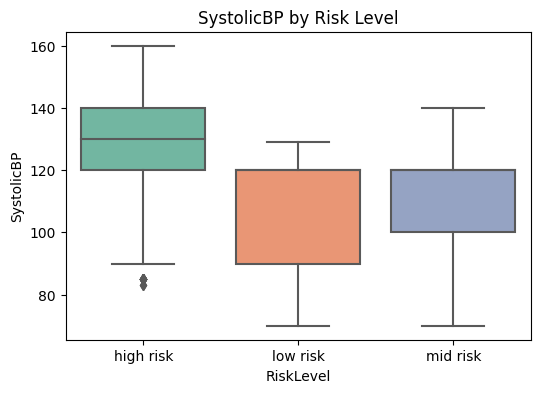

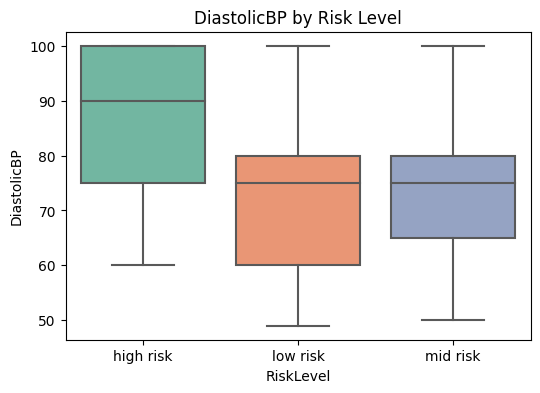

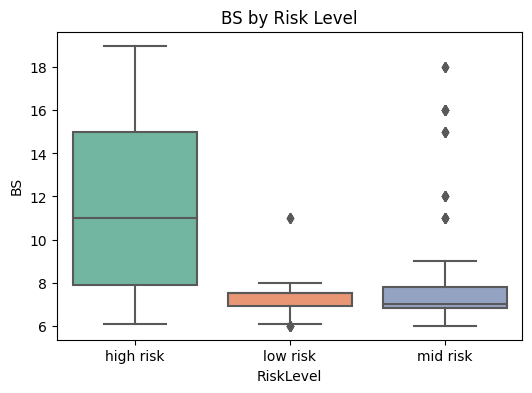

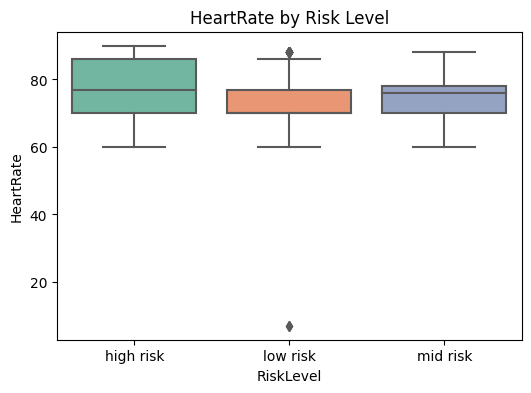

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['SystolicBP','DiastolicBP','BS','HeartRate']

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='RiskLevel', y=col, data=df, palette="Set2")
    plt.title(f"{col} by Risk Level")
    plt.show()
#Higher systolic BP is linked to high risk, showing hypertension’s role in complications like preeclampsia.
#Raised diastolic BP contributes to high risk
#Higher BS levels correlate with higher maternal risk.Gestational diabetes or poor glucose regulation is visible here
#higher risk groups tend to have slightly elevated heart rates.



In [47]:
# Creating Age Categories
df['AgeGroup'] = pd.cut(df['Age'],
                           bins=[0, 19, 34, 100],
                           labels=['Teen', 'Adult', 'Advanced Maternal Age'])

# Checking distribution
print(df['AgeGroup'].value_counts())

Adult                    417
Advanced Maternal Age    318
Teen                     279
Name: AgeGroup, dtype: int64


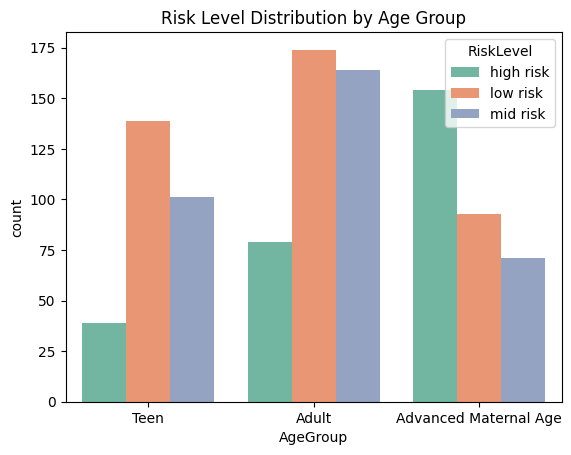

In [48]:
#Visualizing the categories
sns.countplot(x='AgeGroup', hue='RiskLevel', data=df, palette="Set2")
plt.title("Risk Level Distribution by Age Group")
plt.show()

In [49]:
# Hypertension flag
#=1 if Systolic >= 140 or Diastolic >= 90, else 0.
df['Hypertension'] = ((df['SystolicBP'] >= 140) | (df['DiastolicBP'] >= 90)).astype(int)
# Pulse pressure
df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP'] #High pulse pressure (>60 mmHg) can indicate cardiovascular risk.
# Mean arterial pressure
# This reflects overall blood flow and perfusion pressure.
#If MAP is < 70 mmHg it indicates poor perfusion; MAP > 105 mmHg = hypertension risk.
df['MAP'] = (df['SystolicBP'] + 2*df['DiastolicBP']) / 3


In [50]:
#creating blood sugar categories
df['BSGroup'] = pd.cut(df['BS'],
                          bins=[0,7,11,20],
                          labels=['Normal','Pre-diabetic','Diabetic'])

# Checking distribution
print(df['BSGroup'].value_counts())


Pre-diabetic    458
Normal          402
Diabetic        154
Name: BSGroup, dtype: int64


In [51]:
#grouping heart rates
def hr_zone(hr):
    if hr < 60:
        return 'Bradycardia- abnormally low'
    elif hr <= 100:
        return 'Normal'
    else:
        return 'Tachycardia- abnormally high'
df['HRZone'] = df['HeartRate'].apply(hr_zone)

# Checking distribution
print(df['HRZone'].value_counts())


Normal                         1012
Bradycardia- abnormally low       2
Name: HRZone, dtype: int64


In [52]:
df.isnull().sum()

Age              0
SystolicBP       0
DiastolicBP      0
BS               0
BodyTemp         0
HeartRate        0
RiskLevel        0
AgeGroup         0
Hypertension     0
PulsePressure    0
MAP              0
BSGroup          0
HRZone           0
dtype: int64

In [53]:
df.shape

(1014, 13)

In [54]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel', 'AgeGroup', 'Hypertension', 'PulsePressure', 'MAP',
       'BSGroup', 'HRZone'],
      dtype='object')

In [55]:
#detecting outliers
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Example: detect across multiple columns
outlier_indices = []
for col in ['Age','SystolicBP','DiastolicBP','BS','HeartRate']:
    outlier_indices.extend(detect_outliers(col).index)

outlier_indices = list(set(outlier_indices))  # unique rows


In [56]:
#handling outliers
#Capping using clinical threshold
# Applying clinical thresholds
df['SystolicBP'] = np.clip(df['SystolicBP'], 80, 200)   # normal safe range
df['DiastolicBP'] = np.clip(df['DiastolicBP'], 50, 120) # safe range
df['BS'] = np.clip(df['BS'], 3, 20)                     # mmol/L realistic range
df['HeartRate'] = np.clip(df['HeartRate'], 40, 180)     # bpm realistic range
df['Age'] = np.clip(df['Age'], 15, 50)                  # maternal age range


In [57]:
#Scaling continuous features to ensure algorithms like KNN aren’t biased by large-value features.
scaler = StandardScaler()
num_cols = ['Age','SystolicBP','DiastolicBP','BS','HeartRate','PulsePressure','MAP']
df[num_cols] = scaler.fit_transform(df[num_cols])


In [58]:
#Encoding categorical features
# 1. Label Encoding RiskLevel (ordinal)
le = LabelEncoder()
df['RiskLevel'] = le.fit_transform(df['RiskLevel'])

# 2. One-Hot Encoding nominal categories
df = pd.get_dummies(df, 
                    columns=['AgeGroup','BSGroup','HRZone'], 
                    drop_first=True)



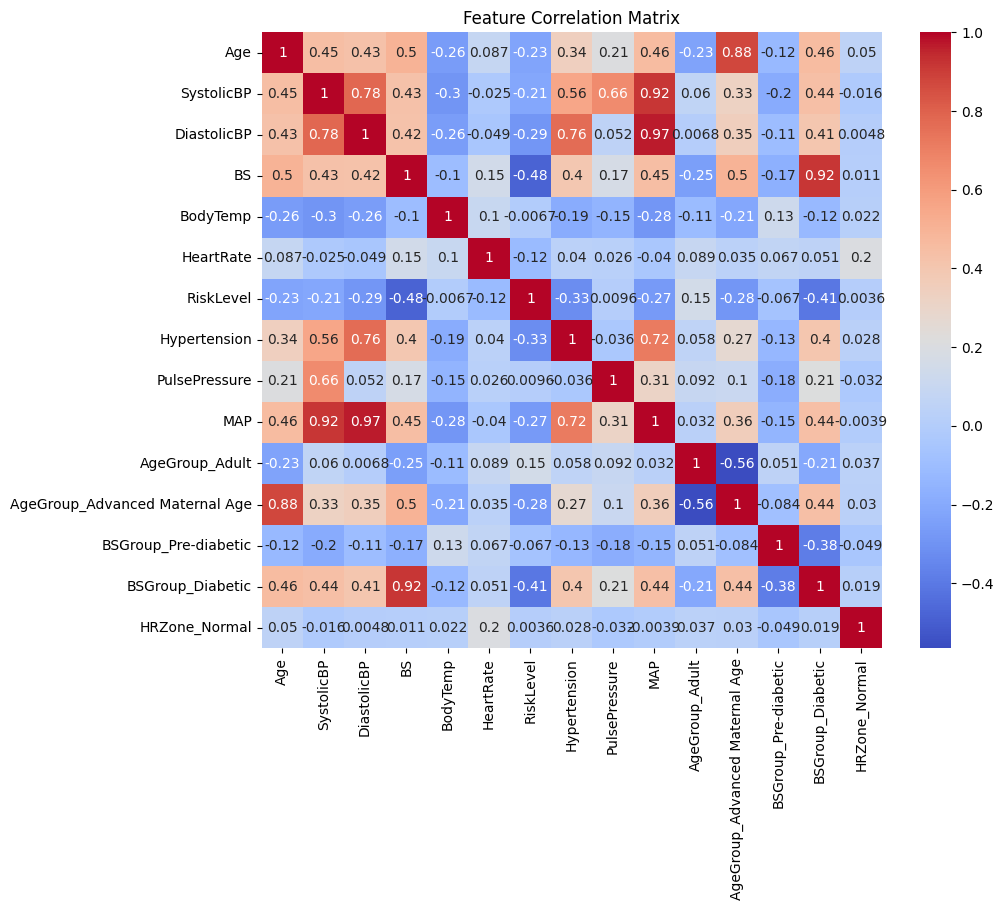

In [59]:
#feature selection
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [60]:
#Ordered Feature Importance
# Separating predictors and target
X = df.drop(columns=['RiskLevel'])   # includes both original + engineered features
y = df['RiskLevel']
# Training a Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)
# Getting feature importance scores
importances = pd.Series(model.feature_importances_, index=X.columns)
# Sorting in descending order
ordered_importances = importances.sort_values(ascending=False)
print(ordered_importances)



BS                                0.397271
SystolicBP                        0.133510
Age                               0.120855
HeartRate                         0.095325
PulsePressure                     0.091031
BodyTemp                          0.052264
MAP                               0.049628
DiastolicBP                       0.034045
AgeGroup_Adult                    0.014102
Hypertension                      0.009752
BSGroup_Pre-diabetic              0.002218
HRZone_Normal                     0.000000
BSGroup_Diabetic                  0.000000
AgeGroup_Advanced Maternal Age    0.000000
dtype: float64


In [61]:
# Dropping irrelevant features
threshold = 0.01   # keep features with importance >= 0.01
# Selecting features above threshold
selected_features = importances[importances >= threshold].index.tolist()
print("Selected features:", selected_features)
# Creating a reduced dataset
X_selected = df[selected_features]
y = df['RiskLevel']


Selected features: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'PulsePressure', 'MAP', 'AgeGroup_Adult']


In [62]:
#SPlitting to training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,          # 20% test, 80% train
    stratify=y,             
    random_state=42         
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (811, 9)
Testing set size: (203, 9)


In [63]:
#Decision tree
#  Splitting dataset (80–20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2, stratify=y, random_state=42
)
# Initializing Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
#  Defining 2-fold cross-validation
kf = KFold(n_splits=2, shuffle=True, random_state=42)
# 4. Runbing Cross Validation on training set
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')
# Training on full training set
dt_model.fit(X_train, y_train)
# Evaluating on test set
dt_test_acc = dt_model.score(X_test, y_test)
# Printing results
print("Decision Tree - CV scores:", dt_cv_scores)
print("Decision Tree - Mean CV accuracy:", dt_cv_scores.mean())
print("Decision Tree - Test accuracy:", dt_test_acc)
#The model generalized well to unseen data
#Gap between the CV and test is small enough to indicate the model isn’t overfitting badly.

Decision Tree - CV scores: [0.76847291 0.74320988]
Decision Tree - Mean CV accuracy: 0.7558413914735753
Decision Tree - Test accuracy: 0.8423645320197044


In [64]:

print(dt_model.classes_)


[0 1 2]


In [65]:
#Getting if/else statements
# Fit the Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
# Export rules as text
tree_rules = export_text(dt_model, feature_names=list(X_train.columns))
print(tree_rules)


|--- BS <= -0.24
|   |--- SystolicBP <= 1.06
|   |   |--- PulsePressure <= 0.95
|   |   |   |--- BodyTemp <= 99.50
|   |   |   |   |--- BS <= -0.52
|   |   |   |   |   |--- BS <= -0.63
|   |   |   |   |   |   |--- MAP <= -2.15
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |--- MAP >  -2.15
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BS >  -0.63
|   |   |   |   |   |   |--- MAP <= -1.45
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- MAP >  -1.45
|   |   |   |   |   |   |   |--- PulsePressure <= 0.24
|   |   |   |   |   |   |   |   |--- SystolicBP <= -0.91
|   |   |   |   |   |   |   |   |   |--- BS <= -0.54
|   |   |   |   |   |   |   |   |   |   |--- Age <= -0.66
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- Age >  -0.66
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- BS >  -0

In [66]:
#Support Vector Machines
#  Initializing SVM 
svm_model = SVC(kernel='linear', random_state=42)
# Defining 2-fold cross-validation
kf = KFold(n_splits=2, shuffle=True, random_state=42)
# Running Cross Validated on training set
svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=kf, scoring='accuracy')
#Training on full training set
svm_model.fit(X_train, y_train)
#Evaluating on test set
svm_test_acc = svm_model.score(X_test, y_test)
#Printing results
print("SVM - CV scores:", svm_cv_scores)
print("SVM - Mean CV accuracy:", svm_cv_scores.mean())
print("SVM - Test accuracy:", svm_test_acc)


SVM - CV scores: [0.64285714 0.64691358]
SVM - Mean CV accuracy: 0.6448853615520282
SVM - Test accuracy: 0.6502463054187192


In [67]:
# Decision Tree outperformed SVM both in CV and test accuracy.
#The Decision Tree is also easier to explain with if/else rules
#SVM is powerful on complex, high‑dimensional data, but here it didn’t capture the patterns as well.

In [68]:
#K-Nearest Neighbours
#Finding a good value of k using cross-validation on the training set
k_values = [3, 5, 7, 9, 11, 15]
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    kf = KFold(n_splits=2, shuffle=True, random_state=42)
    scores = cross_val_score(knn_temp, X_train, y_train, cv=kf, scoring='accuracy')
    k_scores.append(scores.mean())
    print(f"k={k} -> Mean CV accuracy: {scores.mean():.4f}")

best_k = k_values[k_scores.index(max(k_scores))]
print("\nBest k found:", best_k)

k=3 -> Mean CV accuracy: 0.6560
k=5 -> Mean CV accuracy: 0.6584
k=7 -> Mean CV accuracy: 0.6436
k=9 -> Mean CV accuracy: 0.6461
k=11 -> Mean CV accuracy: 0.6412
k=15 -> Mean CV accuracy: 0.6498

Best k found: 5


In [69]:
#Initializing KNN with the best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
#Defining 2-fold cross-validation
kf = KFold(n_splits=2, shuffle=True, random_state=42)
#Running Cross Validation on training set
knn_cv_scores = cross_val_score(knn_model, X_train, y_train, cv=kf, scoring='accuracy')
#Training on full training set
knn_model.fit(X_train, y_train)
#Evaluating on test set
knn_test_acc = knn_model.score(X_test, y_test)
#Printing results
print("KNN - CV scores:", knn_cv_scores)
print("KNN - Mean CV accuracy:", knn_cv_scores.mean())
print("KNN - Test accuracy:", knn_test_acc)

KNN - CV scores: [0.69211823 0.62469136]
KNN - Mean CV accuracy: 0.6584047923128382
KNN - Test accuracy: 0.6995073891625616


In [70]:
#Artificial Neural Network (MLPClassifier)
#Initializing ANN
ann_model = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu',
                           solver='adam', max_iter=2000, random_state=42)
#Defining 2-fold cross-validation
kf = KFold(n_splits=2, shuffle=True, random_state=42)
#Running Cross Validation on training set
ann_cv_scores = cross_val_score(ann_model, X_train, y_train, cv=kf, scoring='accuracy')
#Training on full training set
ann_model.fit(X_train, y_train)
#Evaluating on test set
ann_test_acc = ann_model.score(X_test, y_test)
#Printing results
print("ANN - CV scores:", ann_cv_scores)
print("ANN - Mean CV accuracy:", ann_cv_scores.mean())
print("ANN - Test accuracy:", ann_test_acc)

ANN - CV scores: [0.62807882 0.60740741]
ANN - Mean CV accuracy: 0.6177431125706987
ANN - Test accuracy: 0.6206896551724138


In [72]:
#Comparing all four models
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "SVM", "KNN", "ANN"],
    "Mean CV Accuracy": [dt_cv_scores.mean(), svm_cv_scores.mean(),
                         knn_cv_scores.mean(), ann_cv_scores.mean()],
    "Test Accuracy": [dt_test_acc, svm_test_acc, knn_test_acc, ann_test_acc]
})
comparison = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Mean CV Accuracy,Test Accuracy
0,Decision Tree,0.755841,0.842365
1,KNN,0.658405,0.699507
2,SVM,0.644885,0.650246
3,ANN,0.617743,0.620690


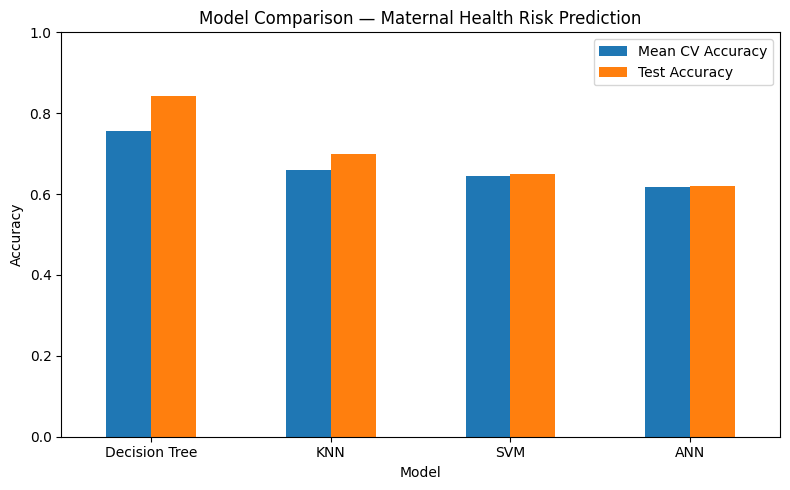

In [73]:
comparison.plot(x="Model", y=["Mean CV Accuracy", "Test Accuracy"], kind="bar", figsize=(8,5))
plt.title("Model Comparison — Maternal Health Risk Prediction")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()